   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1    Male  80.0             0              1          Yes        Private   
2  Female  49.0             0              0          Yes        Private   
3  Female  79.0             1              0          Yes  Self-employed   
4    Male  81.0             0              0          Yes        Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
1          Rural             105.92  32.5     never smoked       1  
2          Urban             171.23  34.4           smokes       1  
3          Rural             174.12  24.0     never smoked       1  
4          Urban             186.21  29.0  formerly smoked       1  
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type     

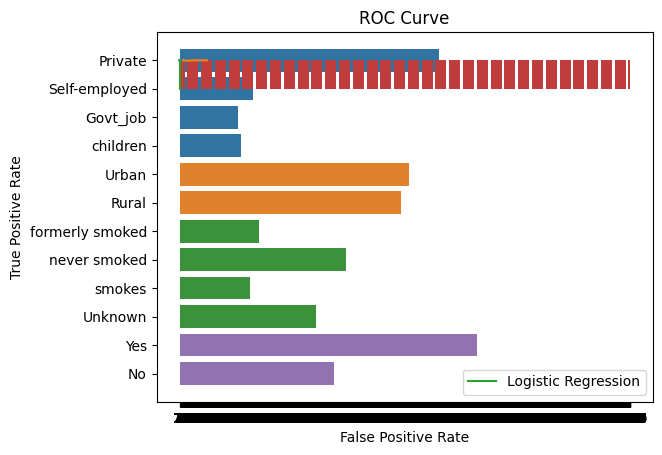

{'Stroke Prediction': 'Yes', 'Probability': np.float64(0.3081377495625653)}
{'Stroke Prediction': 'No', 'Probability': np.float64(0.13736931340349023)}


In [18]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASET
data = pd.read_csv('/content/full_data.csv')

# BASIC CHECKS
print(data.head())
print(data.isnull().sum())

# HANDLE MISSING VALUES
avg = data['bmi'].mean()
data['bmi'].fillna(avg, inplace=True)

# DATA DESCRIPTION
print(data.describe())

# COUNT PLOTS
sns.countplot(data['work_type'])
sns.countplot(data['Residence_type'])
sns.countplot(data['smoking_status'])
sns.countplot(data['stroke'])
sns.countplot(data['ever_married'])

# MIN & MAX VALUES
print(min(data.avg_glucose_level))
print(max(data.avg_glucose_level))

# DISTRIBUTION PLOTS
sns.distplot(data['age'])
sns.distplot(data['avg_glucose_level'])

# DATA ENCODING
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})
data['Residence_type'] = data['Residence_type'].map({'Urban': 1, 'Rural': 0})
data['smoking_status'] = data['smoking_status'].map({
    'formerly smoked': 1,
    'never smoked': 0,
    'smokes': 2,
    'Unknown': 3
})
data['ever_married'] = data['ever_married'].map({'Yes': 1, 'No': 0})

# FEATURE SELECTION
features = ['age', 'hypertension', 'heart_disease', 'ever_married',
            'Residence_type', 'avg_glucose_level', 'bmi', 'gender', 'smoking_status']

X = data[features]
y = data['stroke']

# HANDLE CLASS IMBALANCE USING SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_smote, y_smote = smote.fit_resample(X, y)

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.33, random_state=42
)

# FEATURE SCALING
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# LOGISTIC REGRESSION MODEL
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# PREDICTIONS
y_pred = log_reg.predict(X_test)

# EVALUATION
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))

# ROC CURVE
from sklearn.metrics import roc_curve

y_prob = log_reg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# PREDICTION FUNCTION
def predict_stroke(features_dict):
    input_data = pd.DataFrame([features_dict])
    scaled_data = sc.transform(input_data)

    probability = log_reg.predict_proba(scaled_data)[0][1]

    # change threshold here
    if probability >= 0.3:
        result = "Yes"
    else:
        result = "No"

    return {
        "Stroke Prediction": result,
        "Probability": probability
    }
# EXAMPLE INPUT
example_input = {
    'age': 67,
    'hypertension': 0,
    'heart_disease': 1,
    'ever_married': 0,
    'Residence_type': 1,
    'avg_glucose_level': 105,
    'bmi': 30,
    'gender': 1,
    'smoking_status': 2
}

print(predict_stroke(example_input))

#example input2:
# EXAMPLE INPUT
example_no = {
    'age': 25,
    'hypertension': 0,
    'heart_disease': 0,
    'ever_married': 0,
    'Residence_type': 0,
    'avg_glucose_level': 80,
    'bmi': 22,
    'gender': 0,
    'smoking_status': 0
}

print(predict_stroke(example_no))